<a href="https://colab.research.google.com/github/tudy0406/AI-Goolge-Colab/blob/main/lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 7 - Clustering Algorithms

In this lab you will practice unsupervised learning with **K-Means** and **DBSCAN**, then compare this with hyperparameter tuning for a supervised learning task.

The clustering exercises use a larger synthetic 2D dataset with `x` and `y` coordinates, so the results can be printed, plotted, and inspected like a real clustering problem.

## Exercise 1 - Create and Inspect a 2D Dataset

**Requirements**

- Create a `pandas` DataFrame with two columns: `x` and `y`.
- Generate a larger synthetic dataset with dense groups and outliers.
- Print the first rows of the dataset.
- Plot the points using `matplotlib`.

**Hints**

- Use `make_blobs` to generate compact groups of points.
- Add a few manually chosen outliers with `numpy`.
- Use `pd.DataFrame(points, columns=["x", "y"])` after combining all points.
- Use `plt.scatter(df["x"], df["y"])`.
- This dataset contains three compact groups and several possible noise points.
- `random_state=42` makes the generated points reproducible.

          x         y
0  8.491639  1.646931
1  8.890048  1.541177
2  6.157329  3.266367
3  1.459523  1.094614
4  1.532116  0.504351


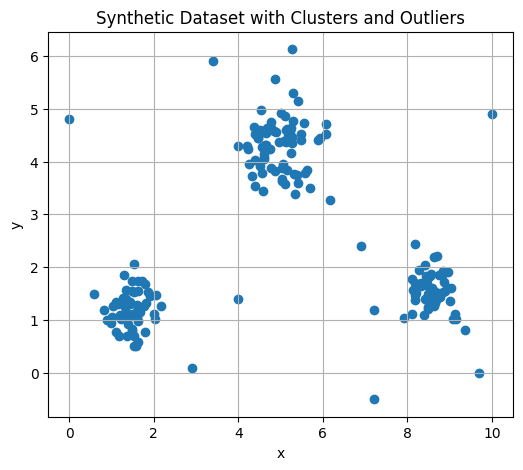

In [1]:
# TODO: imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# TODO: generate clustered points
cluster_points, true_labels = make_blobs(
  n_samples=[60, 70, 55],
  centers=[(1.5, 1.2), (5.0, 4.2), (8.5, 1.6)],
  cluster_std=[0.35, 0.50, 0.40],
  random_state=42
)

# TODO: add possible outliers / noise points
outliers = np.array([
  (0.0, 4.8), (2.9, 0.1), (3.4, 5.9),
  (6.9, 2.4), (10.0, 4.9), (7.2, -0.5),
  (4.0, 1.4), (9.7, 0.0)
 ])

# TODO: combine normal points and outliers
points = np.vstack([cluster_points, outliers])

# TODO: create the DataFrame
df = pd.DataFrame(points, columns=["x", "y"])

# TODO: print the dataset
print(df.head())

# TODO: plot the points
plt.figure(figsize=(6, 5))
plt.scatter(df["x"], df["y"])
plt.title("Synthetic Dataset with Clusters and Outliers")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

## Exercise 2 - K-Means Clustering

**Requirements**

- Apply K-Means to the 2D dataset.
- Use `K = 3` clusters.
- Add the cluster labels to the DataFrame in a new column named `kmeans_cluster`.
- Print the DataFrame with the assigned clusters.
- Print the final centroid coordinates.
- Plot the points colored by cluster and show the centroids.

**Hints**

- Import `KMeans` from `sklearn.cluster`.
- Use `KMeans(n_clusters=3, random_state=42, n_init=10)`.
- Use `model.fit_predict(df[["x", "y"]])`.
- Centroids are stored in `model.cluster_centers_`.

          x         y  kmeans_cluster
0  8.491639  1.646931               1
1  8.890048  1.541177               1
2  6.157329  3.266367               0
3  1.459523  1.094614               2
4  1.532116  0.504351               2
Centroids:
 [[4.96687298 4.31538231]
 [8.55682158 1.55206386]
 [1.49641631 1.2317567 ]]


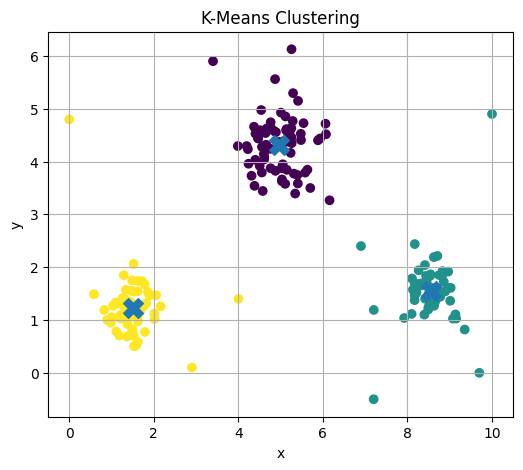

In [9]:
#TODO: import KMeans
from sklearn.cluster import KMeans

# TODO: select the feature columns
X = df[["x", "y"]];

# TODO: create and train the K-Means model
kmeans = KMeans(n_clusters = 3, random_state=42, n_init=10)
df["kmeans_cluster"] = kmeans.fit_predict(X)

# TODO: print the points and their assigned clusters
print(df.head())

# TODO: print the centroids
centroids = kmeans.cluster_centers_
print("Centroids:\n", centroids)

# TODO: plot the clustered points and centroids
plt.figure(figsize=(6, 5))

# plot points colored by cluster
plt.scatter(df["x"], df["y"], c=df["kmeans_cluster"])

# plot centroids
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200)

plt.title("K-Means Clustering")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()


## Exercise 3 - K-Means with Different Values of K

**Requirements**

- Run K-Means for several values of `K`.
- Try `K = 2, 3, 4, 5`.
- For each value, print the inertia.
- Decide which value of `K` looks best for this dataset.

**Hints**

- Inertia is stored in `model.inertia_`.
- Lower inertia is not always enough by itself, because inertia usually decreases when `K` increases.
- You can also plot `K` versus inertia to see the elbow idea.

K=2, inertia=778.0028206512485
K=3, inertia=116.66735275288188
K=4, inertia=104.98907751932167
K=5, inertia=91.46847442367775


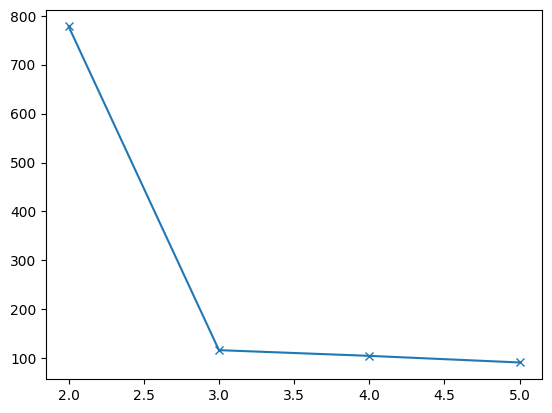

In [12]:
k_values = [2, 3, 4, 5]
inertias = []

# TODO: loop through the values of K
for k in k_values:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertias.append(model.inertia_)
    print(f"K={k}, inertia={model.inertia_}")

# TODO: plot K versus inertia
plt.plot(k_values, inertias, marker='x')

## Exercise 4 - DBSCAN Clustering

**Requirements**

- Apply DBSCAN to the same 2D dataset.
- Add the DBSCAN labels to the DataFrame in a new column named `dbscan_cluster`.
- Print the DataFrame with the assigned clusters.
- Count how many points are marked as noise.
- Plot the points colored by DBSCAN label.

**Hints**

- Import `DBSCAN` from `sklearn.cluster`.
- Try `DBSCAN(eps=0.65, min_samples=5)`.
- In scikit-learn, noise points receive label `-1`.
- DBSCAN does not require the number of clusters as input.

          x         y  dbscan_cluster
0  8.491639  1.646931               0
1  8.890048  1.541177               0
2  6.157329  3.266367               2
3  1.459523  1.094614               1
4  1.532116  0.504351               1
Noise points:  10


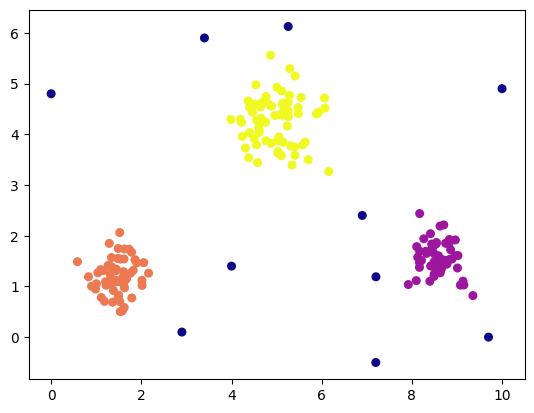

In [17]:
# TODO: import DBSCAN

from sklearn.cluster import DBSCAN

# TODO: create and train the DBSCAN model
dbscan = DBSCAN(eps=0.65, min_samples=5)
df["dbscan_cluster"] = dbscan.fit_predict(X)

# TODO: print the points and their assigned clusters
print(df[["x", "y", "dbscan_cluster"]].head())


# TODO: count noise points
noise_count = (df["dbscan_cluster"] == -1).sum()
print("Noise points: ", noise_count)

# TODO: plot the DBSCAN clusters
plt.scatter(df["x"], df["y"], c=df["dbscan_cluster"], cmap="plasma", s=30)

## Exercise 5 - Compare K-Means and DBSCAN

**Requirements**

- Compare the labels produced by K-Means and DBSCAN.
- Print the columns `x`, `y`, `kmeans_cluster`, and `dbscan_cluster`.
- Answer the questions below in a markdown cell after running the code.

**Questions**

- How many points does DBSCAN mark as noise?
- Which method requires the number of clusters before training?
- Which method is better when the dataset contains noise or outliers?

**Hints**

- K-Means assigns every point to a cluster.
- DBSCAN can mark some points as noise.

In [18]:
# TODO: print a comparison table
comparison = df
print(comparison)

# TODO: write your answers in a markdown cell below this code cell


             x         y  kmeans_cluster  dbscan_cluster
0     8.491639  1.646931               1               0
1     8.890048  1.541177               1               0
2     6.157329  3.266367               0               2
3     1.459523  1.094614               2               1
4     1.532116  0.504351               2               1
..         ...       ...             ...             ...
188   6.900000  2.400000               1              -1
189  10.000000  4.900000               1              -1
190   7.200000 -0.500000               1              -1
191   4.000000  1.400000               2              -1
192   9.700000  0.000000               1              -1

[193 rows x 4 columns]


## Exercise 6 - Internal Evaluation with Silhouette Score

**Requirements**

- Compute the silhouette score for K-Means with `K = 2, 3, 4, 5`.
- Print the score for each value of `K`.
- Select the best value of `K` according to the silhouette score.

**Hints**

- Import `silhouette_score` from `sklearn.metrics`.
- The score range is `[-1, 1]`.
- A score closer to `1` usually means better separated clusters.
- The silhouette score needs at least two clusters.

In [19]:
from sklearn.metrics import silhouette_score

scores = {}

# try different values of k
k_values = range(2, 7)  # silhouette is not defined for k=1

# TODO: compute silhouette scores for K-Means
for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)

    scores[k] = score
    print(f"k={k}, silhouette score={score:.4f}")

# TODO: find and print the best K
best_k = max(scores, key=scores.get)
print(f"\nBest k: {best_k} with score {scores[best_k]:.4f}")


k=2, silhouette score=0.6240
k=3, silhouette score=0.8072
k=4, silhouette score=0.7991
k=5, silhouette score=0.6257
k=6, silhouette score=0.6148

Best k: 3 with score 0.8072


## Exercise 7 - Simple Grid Search for DBSCAN Parameters

**Requirements**

- Try several values for `eps` and `min_samples`.
- For each combination, run DBSCAN.
- Print the number of clusters, number of noise points, and silhouette score when the score can be computed.
- Choose a good parameter combination.

**Hints**

- Try `eps_values = [0.35, 0.50, 0.65, 0.80, 1.00]`.
- Try `min_samples_values = [3, 5, 8, 10]`.
- Ignore label `-1` when counting clusters.
- Silhouette score is only valid when there are at least two non-noise clusters and not all points have the same label.
- This is a manual grid search, not `GridSearchCV`, because DBSCAN is unsupervised.

In [21]:
eps_values = [0.35, 0.50, 0.65, 0.80, 1.00]
min_samples_values = [3, 5, 8, 10]

# TODO: loop through all parameter combinations
for eps in eps_values:
    for min_samples in min_samples_values:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X)

        # number of clusters (excluding noise label -1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        # number of noise points
        n_noise = list(labels).count(-1)

        # silhouette score only valid if >=2 clusters
        if n_clusters >= 2:
            score = silhouette_score(X, labels)
        else:
            score = None

        print(f"eps={eps}, min_samples={min_samples}, "
              f"clusters={n_clusters}, noise={n_noise}, score={score}")


eps=0.35, min_samples=3, clusters=4, noise=16, score=0.5789537792270699
eps=0.35, min_samples=5, clusters=3, noise=22, score=0.6714723919699547
eps=0.35, min_samples=8, clusters=3, noise=24, score=0.6579588462464595
eps=0.35, min_samples=10, clusters=3, noise=28, score=0.6277988236937494
eps=0.5, min_samples=3, clusters=3, noise=12, score=0.7502074964377673
eps=0.5, min_samples=5, clusters=3, noise=12, score=0.7502074964377673
eps=0.5, min_samples=8, clusters=3, noise=15, score=0.725588155259664
eps=0.5, min_samples=10, clusters=3, noise=15, score=0.725588155259664
eps=0.65, min_samples=3, clusters=3, noise=10, score=0.767573606901096
eps=0.65, min_samples=5, clusters=3, noise=10, score=0.767573606901096
eps=0.65, min_samples=8, clusters=3, noise=10, score=0.767573606901096
eps=0.65, min_samples=10, clusters=3, noise=11, score=0.7594415257827053
eps=0.8, min_samples=3, clusters=3, noise=8, score=0.7818696634145835
eps=0.8, min_samples=5, clusters=3, noise=8, score=0.7818696634145835
ep

## Exercise 8 - GridSearchCV for a Supervised Task

**Requirements**

- Load a classification dataset from scikit-learn.
- Split the data into train and test sets.
- Build a pipeline with feature scaling and a classifier.
- Use `GridSearchCV` to tune hyperparameters.
- Print the best parameters, cross-validation score, and test accuracy.

**Dataset**

- Use `load_breast_cancer()` from `sklearn.datasets`.
- It is a built-in binary classification dataset, so no file download is needed.

**Hints**

- Use `train_test_split(..., test_size=0.2, random_state=42, stratify=y)`.
- Use `StandardScaler()` before distance-based models such as KNN.
- Use `KNeighborsClassifier()` as the classifier.
- Example grid:
  - `knn__n_neighbors`: `[3, 5, 7, 9, 11]`
  - `knn__weights`: `["uniform", "distance"]`
  - `knn__metric`: `["euclidean", "manhattan"]`
- Use `GridSearchCV(pipeline, param_grid, cv=5, scoring="accuracy")`.

In [24]:
# TODO: imports
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# TODO: load the dataset
data = load_breast_cancer()
X = data.data
y = data.target

# TODO: split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TODO: create the pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

# TODO: define the parameter grid
param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

# TODO: create and run GridSearchCV
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# TODO: print the best parameters and best cross-validation score

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

# TODO: evaluate the best model on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Best parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 7, 'knn__weights': 'uniform'}
Best CV score: 0.9714285714285715

Test Accuracy: 0.9736842105263158

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96        42
           1       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

